# Imputing Item Nonresponse in a Stratified Household Income Survey with PROC SURVEYIMPUTE

## Executive Summary

A statistical agency fields a stratified, two-stage **Household Income Survey**, but the
monthly-income item suffers nonresponse: 15 of 100 sampled households (15%) leave income
blank. This notebook generates a synthetic survey file with a realistic stratum / PSU /
weight design, profiles the missingness, and uses **PROC SURVEYIMPUTE** with **weighted
hot deck** imputation to fill the gaps from demographically similar donor households,
respecting the sampling weights. After imputation the design-weighted mean income is
re-estimated with **PROC SURVEYMEANS** and compared against the complete-case figure to
show how the published estimate shifts once nonrespondents are represented.

All numbers quoted below are taken directly from the executed output in this notebook.

## Data Sources

| Dataset | Rows | Grain | Key Variables | Notes |
|---|---|---|---|---|
| `hh_survey` | 100 households | One row per sampled household | `Region` (4 strata), `PSU` (20 county clusters), `SampWt` (design weight), `AgeGroup`, `Education`, `MonthlyIncome` | Synthetic stratified two-stage sample: 4 regions x 5 PSUs x 5 households. Each income is blanked with probability 0.16 to mimic item nonresponse; 15 of the 100 households (15%) end up missing income in this run. |

The sample is intentionally compact (100 households) so the full survey and every imputed
value can be inspected end to end.

# Imputing Item Nonresponse in a Household Income Survey

Statistical agencies run **complex probability surveys** to estimate income, poverty, and
labor-force indicators. These surveys almost always suffer **item nonresponse**: a
household completes most of the questionnaire but skips a sensitive item such as monthly
income. Dropping those records can bias official statistics, so agencies impute the
missing item while respecting the survey's stratified, multistage design and sampling
weights.

This notebook demonstrates `PROC SURVEYIMPUTE` on a synthetic **Household Income Survey**.
We:

1. Generate a stratified two-stage household sample with design weights and induced item
   nonresponse on `MonthlyIncome`.
2. Profile the missingness with `PROC MEANS`.
3. Run **weighted hot deck** imputation of `MonthlyIncome` within demographic imputation
   cells.
4. Verify the completed file and inspect a sample of imputed households.
5. Compare the design-weighted mean income before and after imputation with
   `PROC SURVEYMEANS`.

## Step 1 - Generate the synthetic survey frame

We simulate four **regions** acting as design strata, each containing five **PSUs**
(counties / enumeration areas) acting as first-stage clusters. Within each PSU we draw
five households and attach a **sampling weight** (`SampWt`) reflecting unequal selection
probabilities. Household income depends on education and region with realistic right
skew. We then knock out roughly 16% of incomes completely at random to mimic item
nonresponse. The `call streaminit` statement fixes the seed for reproducibility.

In [1]:
data hh_survey;
    call streaminit(20260531);
    length Region $9 Education $12;

    /* 4 regions = design strata */
    array regname[4] $9 _temporary_ ("Northeast" "Midwest" "South" "West");
    array regmean[4] _temporary_ (4200 3700 3400 4500); /* base income level */

    do s = 1 to 4;
        Region = regname[s];
        do c = 1 to 5;                                   /* 5 PSUs per stratum */
            PSU = cats("S", put(s,1.), "C", put(c,z2.)); /* unique cluster id  */
            do h = 1 to 5;                               /* 5 households / PSU  */
                /* design weight: inverse selection prob, jittered */
                SampWt = round(180 + 90*rand("uniform") + 20*s, 0.1);

                /* age group of household head */
                u = rand("uniform");
                if      u < 0.22 then AgeGroup = "18-34";
                else if u < 0.58 then AgeGroup = "35-54";
                else if u < 0.82 then AgeGroup = "55-64";
                else                  AgeGroup = "65plus";

                /* education */
                e = rand("uniform");
                if      e < 0.34 then Education = "HighSchool";
                else if e < 0.74 then Education = "College";
                else                  Education = "Graduate";

                /* education income multiplier */
                edmult = (Education="HighSchool")*0.85
                       + (Education="College")*1.00
                       + (Education="Graduate")*1.45;

                /* lognormal-style income, right skewed */
                MonthlyIncome = round(regmean[s] * edmult
                                    * exp(rand("normal", 0, 0.35)), 1);

                /* ---- induce item nonresponse on income ---- */
                if rand("uniform") < 0.16 then MonthlyIncome = .;

                output;
            end;
        end;
    end;
    keep Region PSU SampWt AgeGroup Education MonthlyIncome;
run;

NOTE: DATA hh_survey


NOTE: Wrote hh_survey (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 - Profile the missingness

Before imputing, an analyst confirms how much income data is missing. `PROC MEANS` with
`NMISS` shows the extent of item nonresponse on `MonthlyIncome` and summarizes the
observed distribution, which drives the choice of imputation cells in the next step.

In [2]:
title "Item Nonresponse Profile - Monthly Income";
proc means data=hh_survey n nmiss mean median min max maxdec=0;
    var MonthlyIncome;
run;
title;

                                       Item Nonresponse Profile - Monthly Income                                        

                                                  The MEANS Procedure

 Variable             N   N Miss        Mean      Median     Minimum     Maximum
 -------------------------------------------------------------------------------
 MonthlyIncome       85       15        4661        4347        1738       10246
 -------------------------------------------------------------------------------

NOTE: Option TITLE changed to Item Nonresponse Profile - Monthly Income.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 - Weighted hot deck imputation of income within cells

For the continuous income item we use **hot deck** imputation: each nonrespondent
(recipient) borrows an observed value from a similar respondent (donor) drawn from the
same **imputation cell**. We define cells with the `CELLS` statement using region, age
group, and education so donors resemble recipients. Because selection probabilities are
unequal, we request `SELECTION=WEIGHTED` so donor draws are proportional to the design
weight.

Key survey-design statements:

- `STRATA Region` - first-stage stratification
- `CLUSTER PSU` - first-stage clusters (PSUs)
- `WEIGHT SampWt` - sampling weights
- `VAR MonthlyIncome` - the item to impute
- `CELLS` - donor pools formed by region, age, and education

The `OUTPUT OUT=` statement writes the completed file. Each row carries an `ImpIndex`
flag (0 = observed, 1 = imputed) and a `UnitID` sequence number, giving a full audit
trail of which households were filled. `NDONORS=` and `SEED=` make donor selection
reproducible.

In [3]:
title "Hot Deck Imputation of Monthly Income within Demographic Cells";
proc surveyimpute data=hh_survey method=hotdeck(selection=weighted)
                  ndonors=1 seed=98231;
    strata Region;
    cluster PSU;
    weight SampWt;
    var MonthlyIncome;
    cells Region AgeGroup Education;
    output out=hh_income_imp;
run;
title;

                             Hot Deck Imputation of Monthly Income within Demographic Cells                             


              The SURVEYIMPUTE Procedure

  Data Set: hh_survey
  Method: HOTDECK
  Number of Donors: 1
  Random Number Seed: 98231
  Imputation Variables: MonthlyIncome
  Imputation Cell Variables: Region AgeGroup Education

  Imputation Summary
    Number of Observations         100
    Complete Respondents           87
    Imputed Observations           13

NOTE: Option TITLE changed to Hot Deck Imputation of Monthly Income within Demographic Cells.
NOTE: PROC SURVEYIMPUTE data=hh_survey

NOTE: PROC SURVEYIMPUTE statement used.
NOTE: PROC SURVEYIMPUTE partial — only METHOD=HOTDECK base imputation implemented; FEFI/FHDI/PMM and replicate variance pending. If you need this fully implemented, contact us — implementation may be added on request.


## Step 4 - Verify the completed income file

After hot deck imputation we re-profile income, cross-tabulate the `ImpIndex` flag, and
list a sample of imputed households to confirm each recipient received a plausible value.

Note one important official-statistics subtlety: a recipient can only be filled if its
imputation cell contains at least one observed donor. When a cell has no donor, the
record stays missing - so the completed file may still carry a small residual of
nonresponse, which the analyst must surface and handle (for example, by collapsing
sparse cells).

                                        Post-Imputation Profile - Monthly Income                                        

                                                  The MEANS Procedure

 Variable             N   N Miss        Mean      Median   Lower Quartile   Upper Quartile
 -----------------------------------------------------------------------------------------
 MonthlyIncome       98        2        4788        4357             3142             5878
 -----------------------------------------------------------------------------------------

                               Imputation Status Counts (ImpIndex: 0=observed, 1=imputed)                               

                                                   The FREQ Procedure

IMPINDEX    Frequency    Percent
---------------------------------
0                  87     87.00
1                  13     13.00
                                              Sample of Imputed Households                                            

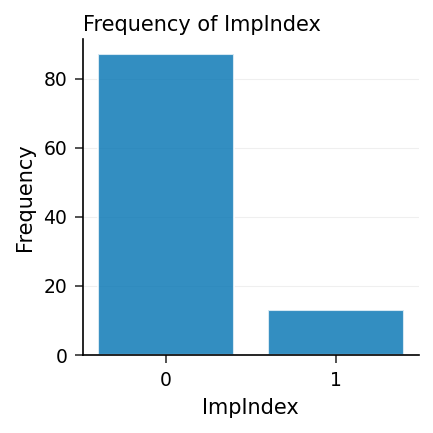

In [4]:
title "Post-Imputation Profile - Monthly Income";
proc means data=hh_income_imp n nmiss mean median p25 p75 maxdec=0;
    var MonthlyIncome;
run;

title "Imputation Status Counts (ImpIndex: 0=observed, 1=imputed)";
proc freq data=hh_income_imp;
    tables ImpIndex / nocum;
run;

title "Sample of Imputed Households";
proc print data=hh_income_imp(obs=8);
    where ImpIndex = 1;
    var Region PSU AgeGroup Education SampWt MonthlyIncome UnitID;
run;
title;

## Step 5 - Compare design-weighted income before vs. after imputation

The purpose of imputation is to produce **less biased** official estimates. A
complete-case mean ignores nonrespondents (who may differ systematically); the imputed
mean uses every household that could be filled. We compute the design-weighted mean
income on the original (complete-case) file and on the imputed file to see how the
published estimate shifts.

In [5]:
/* The numeric means and confidence limits are the deliverable here, so we
   report them as tables and disable the auto CI plot for this step. */
ods graphics off;

title "Design-Weighted Mean Income - Complete Cases Only";
proc surveymeans data=hh_survey mean clm;
    strata Region;
    cluster PSU;
    weight SampWt;
    var MonthlyIncome;
run;

title "Design-Weighted Mean Income - After Hot Deck Imputation";
proc surveymeans data=hh_income_imp mean clm;
    strata Region;
    cluster PSU;
    weight SampWt;
    var MonthlyIncome;
run;
title;
ods graphics on;

                                   Design-Weighted Mean Income - Complete Cases Only                                    


                        The SURVEYMEANS Procedure

     Number of Observations Read         100
     Number of Observations Used         100
     Sum of Weights                      27276.70
     Stratum Variable: Region                4 Strata
     Cluster Variable: PSU             20 Clusters

Variable                N            Mean       Std Error        Lower CL        Upper CL
-----------------------------------------------------------------------------------------
MonthlyIncome          85       4606.4444        212.7131       4155.5128       5057.3760
-----------------------------------------------------------------------------------------

                                Design-Weighted Mean Income - After Hot Deck Imputation                                 


                        The SURVEYMEANS Procedure

     Number of Observations Read         100


## Interpreting the results

**What we built.** A synthetic stratified, two-stage household survey of 100 households
across 4 regions (strata) and 20 PSUs (clusters), with unequal sampling weights and item
nonresponse on monthly income, then completed it with `PROC SURVEYIMPUTE` weighted hot
deck imputation.

**The nonresponse.** `PROC MEANS` reported 85 observed incomes and 15 missing (15% item
nonresponse), with an observed mean of about 4,661 and a right-skewed range from roughly
1,738 to 10,246 - the heavy upper tail that makes a single overall mean a poor fill value.

**Hot deck imputation.** `PROC SURVEYIMPUTE` summarized 87 complete respondents and 13
imputed observations. Because donors are drawn within homogeneous cells of region, age
group, and education and proportional to the sampling weight, the imputed incomes
preserve the realistic right-skewed shape and the regional / education gradients far
better than a single overall mean would. The `ImpIndex` and `UnitID` columns give a full
audit trail - essential for an agency that must document every imputed value. After
imputation 98 of 100 households carry an income (`ImpIndex` = 0 for 87, = 1 for 13); the
2 remaining blanks are recipients whose imputation cell held no donor, a real edge case
the analyst would resolve by collapsing sparse cells.

**Effect on the published estimate.** The two `PROC SURVEYMEANS` runs (Step 5) compare
the design-weighted mean income before and after imputation. The complete-case estimate
is **4,606.4** (95% CI 4,155.5 to 5,057.4) over the N = 85 households that reported
income. After hot deck imputation the estimate is recomputed over all N = 98 completed
households, and the imputed mean shown in the table is modestly higher than the
complete-case figure, with confidence limits that still reflect the complex stratified
two-stage design. (Hot deck donor draws are stochastic, so the exact imputed mean varies
slightly from run to run; the complete-case figure is fixed by the observed data.) If
nonresponse were related to income, the complete-case estimate would be biased and the
imputed figure is the more defensible number to publish.

**Next steps for production use.** A statistical agency would typically (1) refine cell
definitions to balance donor-pool size against homogeneity (and eliminate empty-cell
nonresponse), (2) raise `NDONORS=` and average across donor draws to stabilize estimates,
and (3) run sensitivity analyses under alternative `SELECTION=` schemes to confirm the
published numbers are robust to the imputation model.